### 2. del naloge (Ko imamo dve elastični konstanti)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import KFold

from DataGeneration import theta_time_evolution

plt.rcParams.update({'font.size': 12})

In [2]:
root = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF3\\data\\"

dict_hh = {
    'Kvalues' : np.load(root + "DataK13_hh\\Kvalues.npy"),
    'theta0' : np.load(root + "DataK13_hh\\theta0.npy"),
    'I500_n0' : np.load(root + "DataK13_hh\\intensity500noise0.npy"),
    'I500_n100' : np.load(root + "DataK13_hh\\intensity500noise100.npy"),
    'I505_n0' : np.load(root + "DataK13_hh\\intensity505noise0.npy"),
    'I505_n100' : np.load(root + "DataK13_hh\\intensity505noise100.npy"),
    'I700_n0' : np.load(root + "DataK13_hh\\intensity700noise0.npy"),
    'I700_n100' : np.load(root + "DataK13_hh\\intensity700noise100.npy"),
    'I900_n0' : np.load(root + "DataK13_hh\\intensity900noise0.npy"),
    'I900_n100' : np.load(root + "DataK13_hh\\intensity900noise100.npy")
}

dict_ph = {
    'Kvalues' : np.load(root + "DataK13_ph\\Kvalues.npy"),
    'theta0' : np.load(root + "DataK13_ph\\theta0.npy"),
    'I500_n0' : np.load(root + "DataK13_ph\\intensity500noise0.npy"),
    'I500_n100' : np.load(root + "DataK13_ph\\intensity500noise100.npy"),
    'I505_n0' : np.load(root + "DataK13_ph\\intensity505noise0.npy"),
    'I505_n100' : np.load(root + "DataK13_ph\\intensity505noise100.npy"),
    'I700_n0' : np.load(root + "DataK13_ph\\intensity700noise0.npy"),
    'I700_n100' : np.load(root + "DataK13_ph\\intensity700noise100.npy"),
    'I900_n0' : np.load(root + "DataK13_ph\\intensity900noise0.npy"),
    'I900_n100' : np.load(root + "DataK13_ph\\intensity900noise100.npy")
}

dict_pp = {
    'Kvalues' : np.load(root + "DataK13_pp\\Kvalues.npy"),
    'theta0' : np.load(root + "DataK13_pp\\theta0.npy"),
    'I500_n0' : np.load(root + "DataK13_pp\\intensity500noise0.npy"),
    'I500_n100' : np.load(root + "DataK13_pp\\intensity500noise100.npy"),
    'I505_n0' : np.load(root + "DataK13_pp\\intensity505noise0.npy"),
    'I505_n100' : np.load(root + "DataK13_pp\\intensity505noise100.npy"),
    'I700_n0' : np.load(root + "DataK13_pp\\intensity700noise0.npy"),
    'I700_n100' : np.load(root + "DataK13_pp\\intensity700noise100.npy"),
    'I900_n0' : np.load(root + "DataK13_pp\\intensity900noise0.npy"),
    'I900_n100' : np.load(root + "DataK13_pp\\intensity900noise100.npy")
}

In [ ]:
D = 10 * 1e-6 # Thicknes of layer in meters
n_z = np.shape(dict_hh['theta0'][0])[0]
zs = np.linspace(0, D, n_z) * 1e6 # in um

T = 5 * 1e-6 * (240000 / 600)**2 # Time in seconds
n_t = np.shape(dict_hh['I500_n0'][0])[0]
ts = np.linspace(0, T, n_t)

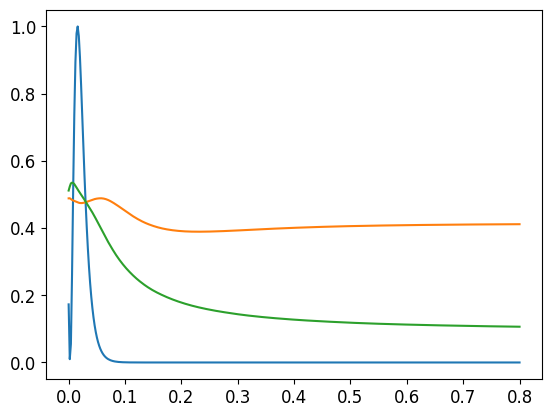

In [ ]:
I_hh = dict_hh['I500_n0'][1]

I_hh = np.average(dict_hh['I500_n0'], axis=0)
I_ph = np.average(dict_ph['I500_n0'], axis=0)
I_pp = np.average(dict_pp['I500_n0'], axis=0)

plt.plot(ts, I_hh)
plt.plot(ts, I_ph)
plt.plot(ts, I_pp)

## konstrukcija nevronske mreže

In [35]:
def create_model(hidden_layers, size, activation):
    model = tf.keras.Sequential()

    # Input layer + prva skrita plast
    model.add(tf.keras.layers.Dense(size[0], activation=activation, input_shape=(400,)))

    # Preostale skrite plasti
    for i in range(1, hidden_layers):
        model.add(tf.keras.layers.Dense(size[i], activation=activation))

    # Izhodna plast
    model.add(tf.keras.layers.Dense(2, activation='sigmoid'))

    # Compile
    model.compile(
        optimizer='adam',
        loss='mean_absolute_error',
        metrics=['mean_squared_error']
    )

    return model


def run_KFold(X, Y, hidden_layers, size, activation, save_path="saved_models"):
    
    # ustvari direktorij za shranjevanje modelov
    os.makedirs(save_path, exist_ok=True)

    kf = KFold(n_splits=5)

    scores_MAE = []
    scores_MSE = []
    histories = []
    best_model_paths = []

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    fold = 1
    for train_idx, test_idx in kf.split(X, Y):

        print(f"Training fold {fold}...")

        model = create_model(hidden_layers, size, activation)

        # pot za shranjevanje najboljšega modela
        model_path = os.path.join(save_path, f"best_model_fold_{fold}.keras")

        checkpoint = tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,   # shrani cel model (struktura + uteži)
            verbose=0
        )

        history = model.fit(
            X[train_idx], Y[train_idx],
            epochs=200,
            batch_size=100,
            verbose=0,
            validation_split=0.1,
            shuffle=True,
            callbacks=[early_stop, checkpoint]
        )

        histories.append(history)
        best_model_paths.append(model_path)

        # naložimo NAJBOLJŠI model iz datoteke
        best_model = tf.keras.models.load_model(model_path)

        # evaluacija najboljšega modela na testnem setu
        mae, mse = best_model.evaluate(X[test_idx], Y[test_idx], verbose=0)

        scores_MAE.append(mae)
        scores_MSE.append(mse)

        print(f" Fold {fold} → MAE = {mae:.4f}, MSE = {mse:.4f}")
        fold += 1

    # -----------------------------
    # Rezultati
    # -----------------------------
    print("\n============================")
    print("FINAL RESULTS OVER ALL FOLDS")
    print("============================")

    print(f"Average MAE: {np.mean(scores_MAE):.4f} ± {np.std(scores_MAE):.4f}")
    print(f"Average MSE: {np.mean(scores_MSE):.4f} ± {np.std(scores_MSE):.4f}")

    return scores_MAE, scores_MSE, histories


In [ ]:
# Kmax = 20e-12
# sidranje = "pp"
# folder = f"TestNTrain_{sidranje}\\"

# # združi vse I*_n100
# X100 = np.concatenate([dict_pp['I500_n100'], dict_pp['I505_n100'], dict_pp['I700_n100'], dict_pp['I900_n100']], axis=0)
# X = np.concatenate([dict_pp['I500_n0'], dict_pp['I505_n0'], dict_pp['I700_n0'], dict_pp['I900_n0']], axis=0)
# Y = np.concatenate([dict_pp['Kvalues'], dict_pp['Kvalues'], dict_pp['Kvalues'], dict_pp['Kvalues']], axis=0)/Kmax

# # shuffle indeksov
# indices = np.arange(X100.shape[0])
# np.random.shuffle(indices)

# X100 = X100[indices]
# X = X[indices]
# Y = Y[indices]

# # Razdelitev na train/test
# n = X.shape[0]
# nt = int(0.9 * n)

# X100_train = X100[:nt]
# X100_test  = X100[nt:]
# X_train = X[:nt]
# X_test  = X[nt:]

# Y_train = Y[:nt]
# Y_test  = Y[nt:]

# print(X100_train.shape, X100_test.shape, Y_train.shape, Y_test.shape)

# # Shrani podatke
# np.save(root + folder + "X100.npy", X100_train)
# np.save(root + folder + "X100_test.npy", X100_test)
# np.save(root + folder + "X.npy", X_train)
# np.save(root + folder + "X_test.npy", X_test)
# np.save(root + folder + "Y.npy", Y_train)
# np.save(root + folder + "Y_test.npy", Y_test)

(360000, 400) (40000, 400) (360000, 2) (40000, 2)


In [36]:
### --- hh train --- ###

X = np.load(root + "TestNTrain_hh\\X.npy")
X100 = np.load(root + "TestNTrain_hh\\X100.npy")
X_test  = np.load(root + "TestNTrain_hh\\X_test.npy")
X100_test  = np.load(root + "TestNTrain_hh\\X100_test.npy")
Y = np.load(root + "TestNTrain_hh\\Y.npy") # Y so že shranjeni normalizirani!!!
Y_test = np.load(root + "TestNTrain_hh\\Y_test.npy")

hidden_layers = 3
size = [200, 100, 50]
activation = 'relu'
save_path0 = f"models3\\model0_hh"
save_path100 = f"models3\\model100_hh"

MAE0_hh, MSE0_hh, histories0_hh = run_KFold(X, Y, hidden_layers, size, activation, save_path0)
MAE100_hh, MSE100_hh, histories100_hh = run_KFold(X100, Y, hidden_layers, size, activation, save_path100)

Training fold 1...


c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Fold 1 → MAE = 0.0893, MSE = 0.0238
Training fold 2...
 Fold 2 → MAE = 0.1141, MSE = 0.0326
Training fold 3...
 Fold 3 → MAE = 0.1150, MSE = 0.0326
Training fold 4...
 Fold 4 → MAE = 0.1173, MSE = 0.0335
Training fold 5...
 Fold 5 → MAE = 0.1154, MSE = 0.0335

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1102 ± 0.0105
Average MSE: 0.0312 ± 0.0037
Training fold 1...
 Fold 1 → MAE = 0.1805, MSE = 0.0552
Training fold 2...
 Fold 2 → MAE = 0.1800, MSE = 0.0545
Training fold 3...
 Fold 3 → MAE = 0.1816, MSE = 0.0563
Training fold 4...
 Fold 4 → MAE = 0.1812, MSE = 0.0558
Training fold 5...
 Fold 5 → MAE = 0.1804, MSE = 0.0553

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1807 ± 0.0006
Average MSE: 0.0554 ± 0.0006


In [37]:
### --- ph train --- ###

X = np.load(root + "TestNTrain_ph\\X.npy")
X100 = np.load(root + "TestNTrain_ph\\X100.npy")
X_test  = np.load(root + "TestNTrain_ph\\X_test.npy")
X100_test  = np.load(root + "TestNTrain_ph\\X100_test.npy")
Y = np.load(root + "TestNTrain_ph\\Y.npy") # Y so že shranjeni normalizirani!!!
Y_test = np.load(root + "TestNTrain_ph\\Y_test.npy")

hidden_layers = 3
size = [200, 100, 50]
activation = 'relu'
save_path0 = f"models3\\model0_ph"
save_path100 = f"models3\\model100_ph"

MAE0_ph, MSE0_ph, histories0_ph = run_KFold(X, Y, hidden_layers, size, activation, save_path0)
MAE100_ph, MSE100_ph, histories100_ph = run_KFold(X100, Y, hidden_layers, size, activation, save_path100)

Training fold 1...


c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Fold 1 → MAE = 0.1204, MSE = 0.0343
Training fold 2...
 Fold 2 → MAE = 0.1397, MSE = 0.0400
Training fold 3...
 Fold 3 → MAE = 0.1420, MSE = 0.0409
Training fold 4...
 Fold 4 → MAE = 0.1414, MSE = 0.0416
Training fold 5...
 Fold 5 → MAE = 0.1438, MSE = 0.0426

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1375 ± 0.0086
Average MSE: 0.0399 ± 0.0029
Training fold 1...
 Fold 1 → MAE = 0.1577, MSE = 0.0480
Training fold 2...
 Fold 2 → MAE = 0.1620, MSE = 0.0490
Training fold 3...
 Fold 3 → MAE = 0.1607, MSE = 0.0483
Training fold 4...
 Fold 4 → MAE = 0.1606, MSE = 0.0490
Training fold 5...
 Fold 5 → MAE = 0.1629, MSE = 0.0495

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1608 ± 0.0017
Average MSE: 0.0487 ± 0.0005


In [38]:
### --- pp train --- ###

X = np.load(root + "TestNTrain_pp\\X.npy")
X100 = np.load(root + "TestNTrain_pp\\X100.npy")
X_test  = np.load(root + "TestNTrain_pp\\X_test.npy")
X100_test  = np.load(root + "TestNTrain_pp\\X100_test.npy")
Y = np.load(root + "TestNTrain_pp\\Y.npy") # Y so že shranjeni normalizirani!!!
Y_test = np.load(root + "TestNTrain_pp\\Y_test.npy")

hidden_layers = 3
size = [200, 100, 50]
activation = 'relu'
save_path0 = f"models3\\model0_pp"
save_path100 = f"models3\\model100_pp"

MAE0_pp, MSE0_pp, histories0_pp = run_KFold(X, Y, hidden_layers, size, activation, save_path0)
MAE100_pp, MSE100_pp, histories100_pp = run_KFold(X100, Y, hidden_layers, size, activation, save_path100)

Training fold 1...
 Fold 1 → MAE = 0.1092, MSE = 0.0313
Training fold 2...
 Fold 2 → MAE = 0.1318, MSE = 0.0373
Training fold 3...
 Fold 3 → MAE = 0.1306, MSE = 0.0383
Training fold 4...
 Fold 4 → MAE = 0.1274, MSE = 0.0369
Training fold 5...
 Fold 5 → MAE = 0.1274, MSE = 0.0370

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1253 ± 0.0082
Average MSE: 0.0362 ± 0.0025
Training fold 1...
 Fold 1 → MAE = 0.1577, MSE = 0.0465
Training fold 2...
 Fold 2 → MAE = 0.1597, MSE = 0.0470
Training fold 3...
 Fold 3 → MAE = 0.1601, MSE = 0.0474
Training fold 4...
 Fold 4 → MAE = 0.1606, MSE = 0.0478
Training fold 5...
 Fold 5 → MAE = 0.1601, MSE = 0.0471

FINAL RESULTS OVER ALL FOLDS
Average MAE: 0.1596 ± 0.0010
Average MSE: 0.0472 ± 0.0004


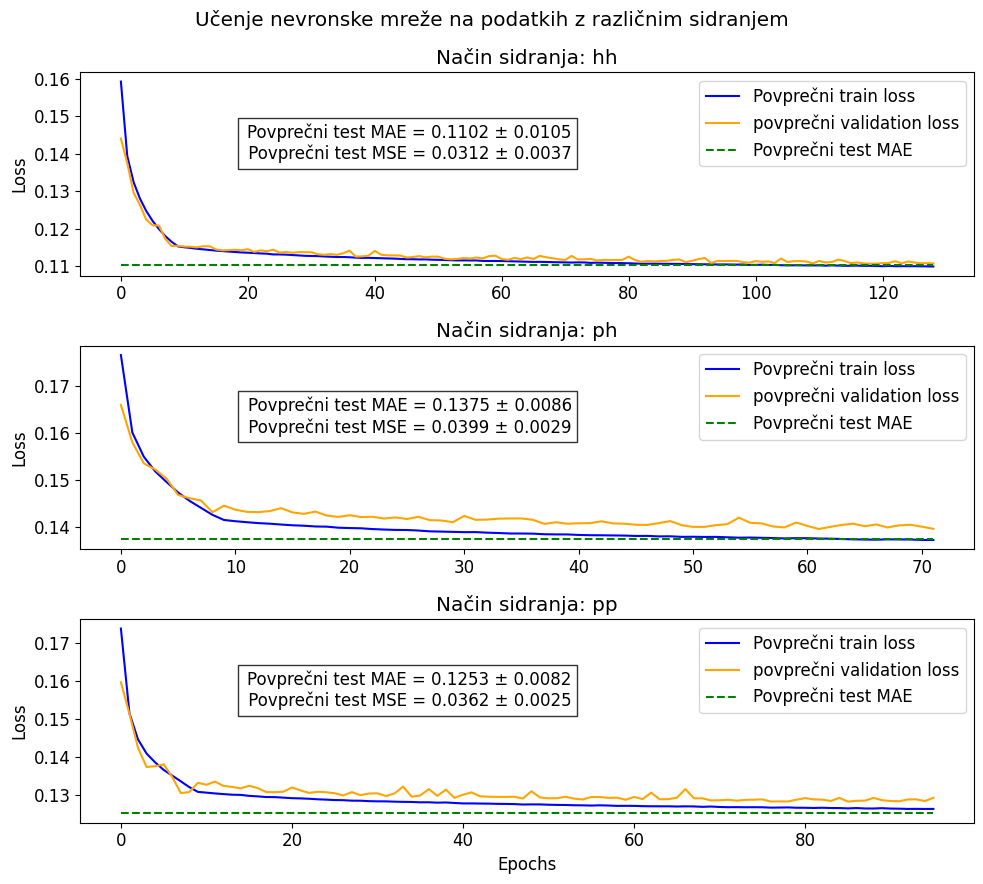

In [40]:
sidranje = ['hh', 'ph', 'pp']
histories_all = [histories0_hh, histories0_ph, histories0_pp]
scores_all = [MAE0_hh, MAE0_ph, MAE0_pp]

MAEs = ["0.1102 ± 0.0105", "0.1375 ± 0.0086", "0.1253 ± 0.0082"]
MSEs = ["0.0312 ± 0.0037", "0.0399 ± 0.0029", "0.0362 ± 0.0025"]

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
fig.suptitle(r'Učenje nevronske mreže na podatkih z različnim sidranjem')
for i, (sid, histories, scores) in enumerate(zip(sidranje, histories_all, scores_all)):
    
    # združi train in val loss vseh fold-ov
    max_epochs = max([len(h.history['loss']) for h in histories])
    train_losses = np.zeros((len(histories), max_epochs))
    val_losses = np.zeros((len(histories), max_epochs))
    
    for j, h in enumerate(histories):
        le = len(h.history['loss'])
        train_losses[j, :le] = h.history['loss']
        val_losses[j, :le] = h.history['val_loss']
        if le < max_epochs:
            # napolni preostanek z zadnjo vrednostjo
            train_losses[j, le:] = h.history['loss'][-1]
            val_losses[j, le:] = h.history['val_loss'][-1]

    # povprečje čez fold-e
    mean_train = np.mean(train_losses, axis=0)
    mean_val = np.mean(val_losses, axis=0)
    
    axes[i].plot(mean_train, label='Povprečni train loss', color='blue')
    axes[i].plot(mean_val, label='povprečni validation loss', color='orange')
    
    # povprečen test MAE čez fold-e
    axes[i].hlines(np.mean(scores), 0, max_epochs-1, colors='green', linestyles='dashed', label='Povprečni test MAE')
    
    # dodaj tekst z MAE in MSE
    text_str = f"Povprečni test MAE = {MAEs[i]}\n Povprečni test MSE = {MSEs[i]}"
    axes[i].text(0.55, 0.75, text_str,
                 transform=axes[i].transAxes,  # koordinate od 0 do 1 v subplotu
                 verticalalignment='top',
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', alpha=0.8))

    axes[i].set_title(f'Način sidranja: {sid}')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

axes[-1].set_xlabel('Epochs')
plt.tight_layout()
plt.show()


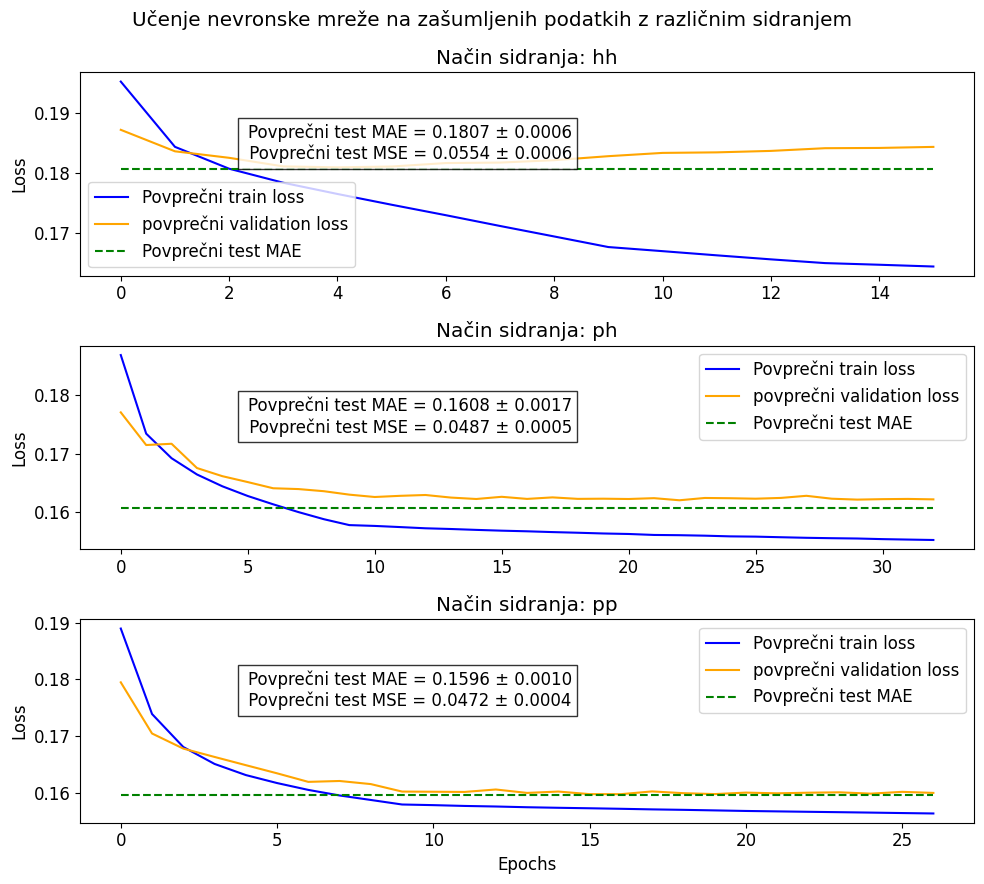

In [43]:
sidranje = ['hh', 'ph', 'pp']
histories_all = [histories100_hh, histories100_ph, histories100_pp]
scores_all = [MAE100_hh, MAE100_ph, MAE100_pp]

MAEs = ["0.1807 ± 0.0006", "0.1608 ± 0.0017", "0.1596 ± 0.0010"]
MSEs = ["0.0554 ± 0.0006", "0.0487 ± 0.0005", "0.0472 ± 0.0004"]

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
fig.suptitle(r'Učenje nevronske mreže na zašumljenih podatkih z različnim sidranjem')
for i, (sid, histories, scores) in enumerate(zip(sidranje, histories_all, scores_all)):
    
    # združi train in val loss vseh fold-ov
    max_epochs = max([len(h.history['loss']) for h in histories])
    train_losses = np.zeros((len(histories), max_epochs))
    val_losses = np.zeros((len(histories), max_epochs))
    
    for j, h in enumerate(histories):
        le = len(h.history['loss'])
        train_losses[j, :le] = h.history['loss']
        val_losses[j, :le] = h.history['val_loss']
        if le < max_epochs:
            # napolni preostanek z zadnjo vrednostjo
            train_losses[j, le:] = h.history['loss'][-1]
            val_losses[j, le:] = h.history['val_loss'][-1]

    # povprečje čez fold-e
    mean_train = np.mean(train_losses, axis=0)
    mean_val = np.mean(val_losses, axis=0)
    
    axes[i].plot(mean_train, label='Povprečni train loss', color='blue')
    axes[i].plot(mean_val, label='povprečni validation loss', color='orange')
    
    # povprečen test MAE čez fold-e
    axes[i].hlines(np.mean(scores), 0, max_epochs-1, colors='green', linestyles='dashed', label='Povprečni test MAE')
    
    # dodaj tekst z MAE in MSE
    text_str = f"Povprečni test MAE = {MAEs[i]}\n Povprečni test MSE = {MSEs[i]}"
    axes[i].text(0.55, 0.75, text_str,
                 transform=axes[i].transAxes,  # koordinate od 0 do 1 v subplotu
                 verticalalignment='top',
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', alpha=0.8))

    axes[i].set_title(f'Način sidranja: {sid}')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

axes[-1].set_xlabel('Epochs')
plt.tight_layout()
plt.show()
